![tasks](../docs/tasks.png)


# SVMモデルの構築

In [7]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from datetime import datetime
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree

import graphviz
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)

In [5]:
x_train = pd.read_csv('../data/treated-data/task1/df_x_train.csv')
y_train = pd.read_csv('../data/treated-data/task1/df_y_train.csv')
x_test = pd.read_csv('../data/treated-data/task1/df_x_test.csv')
y_test = pd.read_csv('../data/treated-data/task1/df_y_test.csv')
columns = x_train.columns

In [8]:
svm_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", probability=True, random_state=42))
])
svm_model.fit(x_train, y_train)

,steps,"[('scaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


## 変数重要度

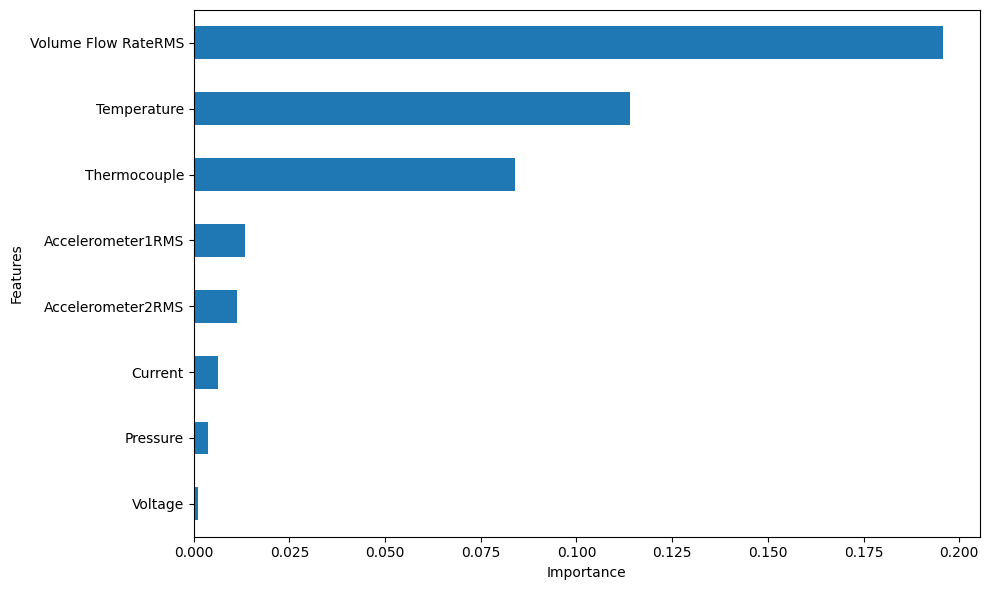

In [11]:
features = x_train.columns


perm_importance = permutation_importance(svm_model, x_test, y_test, n_repeats=10, random_state=42)
svm_imp = pd.Series(perm_importance.importances_mean, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
svm_imp.plot(kind='barh')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## SHAP値

ExactExplainer explainer: 1012it [10:18,  1.61it/s]                          


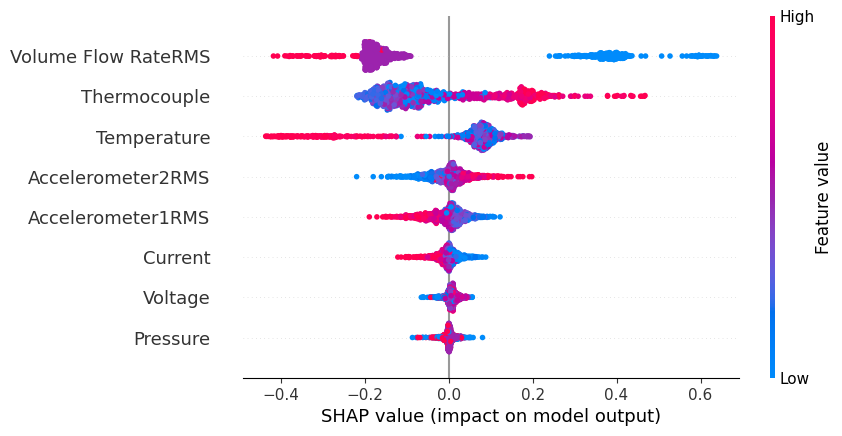

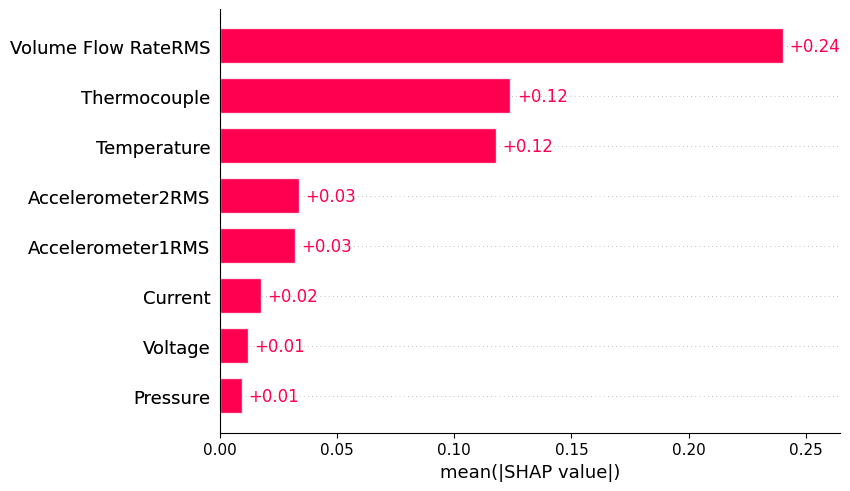

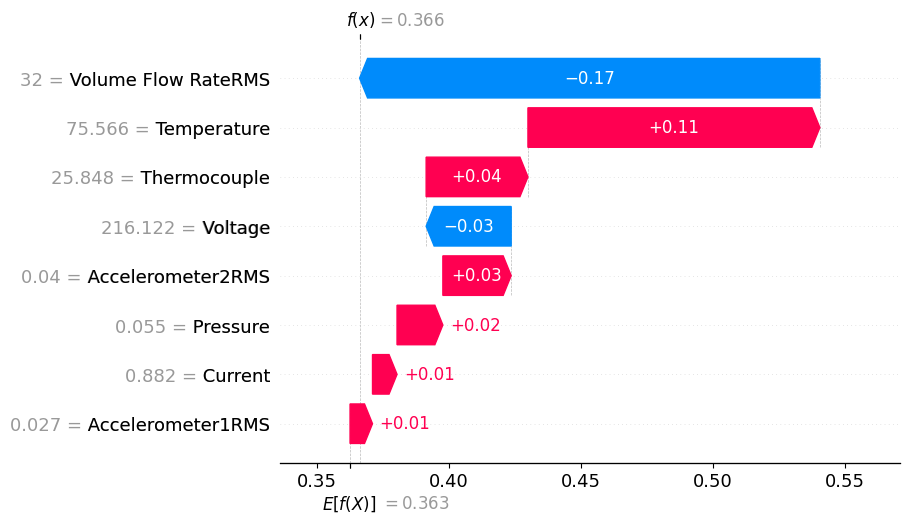

In [9]:
if hasattr(x_train, "sample"):
    X_bg = x_train.sample(n=min(100, len(x_train)), random_state=42)
else:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(x_train), size=min(100, len(x_train)), replace=False)
    X_bg = x_train[idx]

masker = shap.maskers.Independent(X_bg)

explainer_svm = shap.Explainer(
    svm_model.predict_proba,
    masker
)

X_explain = x_test
shap_exp = explainer_svm(X_explain)
shap_exp_c1 = shap_exp[:, :, 1]   # クラス1

# (1) SHAP summary plot（beeswarm）
shap.plots.beeswarm(shap_exp_c1)

# (2) SHAP summary plot（bar）
shap.plots.bar(shap_exp_c1)

# (3) waterfall（代表サンプル1件）
i = 0  # 代表サンプル番号（必要に応じて変更）
shap.plots.waterfall(shap_exp_c1[i])